<a href="https://colab.research.google.com/github/gsaivarshini10/qubit-efficient-hybrid-quantum-reinforcement-learning-for-vrp/blob/main/QRl_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pennylane torch matplotlib numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 132.9 MB/s eta 0:00:00


In [ ]:
"""
Hybrid QRL for VRP with PennyLane (fully corrected)
- Attention-based classical encoder
- Quantum policy layer (PennyLane)
- REINFORCE training
- Reports best route, distance, memory usage
- No dtype errors
"""

import os
import random
import psutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml

# -------------------------------
# VRP Environment
# -------------------------------
class VRPEnvironment:
    def __init__(self, customers, num_vehicles=2):
        self.depot = np.array([0.0, 0.0], dtype=np.float32)
        self.customers = np.array(customers, dtype=np.float32)
        self.num_customers = len(self.customers)
        self.num_vehicles = num_vehicles
        self.reset()

    def reset(self):
        self.visited = np.zeros(self.num_customers, dtype=bool)
        self.vehicle_positions = np.tile(self.depot, (self.num_vehicles, 1)).astype(np.float32)
        self.total_distance = 0.0
        return self._get_state()

    def _distance(self, a, b):
        return np.linalg.norm(a - b)

    def _get_state(self):
        return np.concatenate([self.vehicle_positions.flatten(),
                               self.customers.flatten(),
                               self.visited.astype(np.float32)])

    def step(self, vehicle_idx, customer_idx):
        if self.visited[customer_idx]:
            return self._get_state(), -5.0, all(self.visited), 0.0
        curr = self.vehicle_positions[vehicle_idx]
        target = self.customers[customer_idx]
        dist = self._distance(curr, target)
        self.vehicle_positions[vehicle_idx] = target.copy()
        self.visited[customer_idx] = True
        self.total_distance += dist
        done = all(self.visited)
        reward = -dist
        return self._get_state(), reward, done, dist

# -------------------------------
# Quantum circuit (PennyLane)
# -------------------------------
n_qubits = 6
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def q_policy_qnode(encoded_angles, q_weights):
    # encoded_angles and q_weights are torch tensors (float32)
    encoded_angles = encoded_angles.float()
    q_weights = q_weights.float()
    for i in range(n_qubits):
        qml.RY(encoded_angles[i], wires=i)
    for i in range(n_qubits):
        qml.RY(q_weights[i,0], wires=i)
        qml.RZ(q_weights[i,1], wires=i)
        qml.RX(q_weights[i,2], wires=i)
    for i in range(n_qubits-1):
        qml.CNOT(wires=[i,i+1])
    qml.CNOT(wires=[n_qubits-1,0])
    return qml.expval(qml.PauliZ(0))

# -------------------------------
# Hybrid Attention + Quantum Policy
# -------------------------------
class HybridQRLPolicy(nn.Module):
    def __init__(self, embed_dim=64, n_heads=4, n_qubits_local=n_qubits):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_heads = n_heads
        self.n_qubits = n_qubits_local

        self.customer_embed = nn.Sequential(
            nn.Linear(3, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        self.vehicle_embed = nn.Sequential(
            nn.Linear(2, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        self.attention = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.classical_to_qubits = nn.Linear(embed_dim, self.n_qubits)
        self.q_weights = nn.Parameter(0.01 * torch.randn(self.n_qubits,3,dtype=torch.float32))
        self.post_proc = nn.Linear(1,1)

    def forward(self, vehicle_positions_np, customer_positions_np, visited_mask_np):
        device = next(self.parameters()).device
        vehicle_positions = torch.tensor(vehicle_positions_np, dtype=torch.float32, device=device)
        customer_positions = torch.tensor(customer_positions_np, dtype=torch.float32, device=device)
        visited_mask = torch.tensor(visited_mask_np, dtype=torch.float32, device=device)

        num_vehicles = vehicle_positions.shape[0]
        num_customers = customer_positions.shape[0]

        customer_input = torch.cat([customer_positions, visited_mask.unsqueeze(1)], dim=1)
        cust_emb = self.customer_embed(customer_input)
        veh_emb = self.vehicle_embed(vehicle_positions)
        queries = veh_emb.unsqueeze(0)
        keys_values = cust_emb.unsqueeze(0)
        attn_output, _ = self.attention(queries, keys_values, keys_values)
        attn_output = attn_output.squeeze(0)

        scores = torch.zeros((num_vehicles, num_customers), device=device, dtype=torch.float32)

        for v in range(num_vehicles):
            v_vec = attn_output[v].unsqueeze(0)
            pair_features = v_vec * cust_emb
            angles = self.classical_to_qubits(pair_features)
            angles = torch.tanh(angles) * np.pi
            for c in range(num_customers):
                if visited_mask[c] >= 0.5:
                    scores[v,c] = -1e6
                    continue
                encoded_angles = angles[c]
                q_out = q_policy_qnode(encoded_angles, self.q_weights)
                q_out = q_out.float()  # FIX dtype mismatch
                q_score = self.post_proc(q_out.unsqueeze(0)).squeeze(0)
                scores[v,c] = (q_score + 1.0) * 0.5
        probs = torch.softmax(scores, dim=1)
        return probs

# -------------------------------
# REINFORCE training
# -------------------------------
def train_hybrid_qrl(customers,
                     num_vehicles=2,
                     episodes=50,
                     max_steps_per_episode=200,
                     lr=0.01,
                     save_path="hybrid_qrl.pth",
                     device="cpu"):
    env = VRPEnvironment(customers, num_vehicles=num_vehicles)
    policy = HybridQRLPolicy().to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    best_distance = float("inf")
    best_route = None
    episode_rewards = []
    mem_usage_records = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0.0
        route_log = [[] for _ in range(env.num_vehicles)]
        done = False
        steps = 0

        while not done and steps < max_steps_per_episode:
            vehicle_positions = env.vehicle_positions.copy()
            customer_positions = env.customers.copy()
            visited_mask = env.visited.astype(np.float32)
            probs = policy(vehicle_positions, customer_positions, visited_mask)
            probs_np = probs.detach().cpu().numpy()
            flat = probs_np.flatten()
            flat = np.maximum(flat, 0)
            if flat.sum() == 0:
                break
            flat = flat / flat.sum()
            idx = np.random.choice(len(flat), p=flat)
            vehicle_idx = idx // env.num_customers
            customer_idx = idx % env.num_customers
            _, reward, done, dist = env.step(vehicle_idx, customer_idx)
            total_reward += reward
            route_log[vehicle_idx].append(f"C{customer_idx+1}")

            optimizer.zero_grad()
            probs_tensor = policy(vehicle_positions, customer_positions, visited_mask)
            prob_taken = probs_tensor[vehicle_idx, customer_idx]
            loss = -torch.log(prob_taken + 1e-8) * reward
            loss.backward()
            optimizer.step()
            steps += 1

        episode_rewards.append(total_reward)
        mem = psutil.Process(os.getpid()).memory_info().rss / (1024*1024)
        mem_usage_records.append(mem)
        if env.total_distance < best_distance:
            best_distance = env.total_distance
            best_route = route_log

        print(f"Episode {ep+1}/{episodes}  Distance: {env.total_distance:.3f}  Reward: {total_reward:.3f}  Mem(MB): {mem:.1f}")

    torch.save(policy.state_dict(), save_path)
    avg_mem = float(np.mean(mem_usage_records))

    return policy, best_route, best_distance, episode_rewards, avg_mem

# -------------------------------
# MAIN
# -------------------------------
if __name__ == "__main__":
    customers = [
        (2, 3), (5, 4), (6, 1), (3, 6), (4, 2),
        (0, 1), (10, 5), (1, 1), (2, 4), (4, 4)
    ]
    num_vehicles = 2
    episodes = 50
    device = "cpu"
    save_path = "hybrid_qrl_policy.pth"

    # Train
    policy, best_route, best_distance, rewards, avg_mem = train_hybrid_qrl(
        customers, num_vehicles=num_vehicles, episodes=episodes, save_path=save_path, device=device
    )

    print("\n=== Training finished ===")
    print("Best distance found:", best_distance)
    print("Best route (per vehicle):", best_route)
    print(f"Average memory usage during training: {avg_mem:.2f} MB")


Episode 1/50  Distance: 36.677  Reward: -36.677  Mem(MB): 959.3
Episode 2/50  Distance: 48.875  Reward: -48.875  Mem(MB): 960.7
Episode 3/50  Distance: 40.201  Reward: -40.201  Mem(MB): 960.9
Episode 4/50  Distance: 43.113  Reward: -43.113  Mem(MB): 961.0
Episode 5/50  Distance: 37.655  Reward: -37.655  Mem(MB): 961.0
Episode 6/50  Distance: 38.838  Reward: -38.838  Mem(MB): 961.0
Episode 7/50  Distance: 47.435  Reward: -47.435  Mem(MB): 961.0
Episode 8/50  Distance: 41.193  Reward: -41.193  Mem(MB): 961.1
Episode 9/50  Distance: 42.929  Reward: -42.929  Mem(MB): 961.1
Episode 10/50  Distance: 40.752  Reward: -40.752  Mem(MB): 961.1
Episode 11/50  Distance: 46.314  Reward: -46.314  Mem(MB): 961.1
Episode 12/50  Distance: 45.478  Reward: -45.478  Mem(MB): 961.1
Episode 13/50  Distance: 42.431  Reward: -42.431  Mem(MB): 961.1
Episode 14/50  Distance: 49.579  Reward: -49.579  Mem(MB): 961.1
Episode 15/50  Distance: 40.089  Reward: -40.089  Mem(MB): 961.1
Episode 16/50  Distance: 33.040  R

Episode 1  Distance: 34.966  Reward: -34.966  Mem(MB): 873.6
Episode 2  Distance: 36.934  Reward: -36.934  Mem(MB): 875.1
Episode 3  Distance: 44.974  Reward: -44.974  Mem(MB): 875.4
Episode 4  Distance: 31.330  Reward: -31.330  Mem(MB): 875.5
Episode 5  Distance: 33.183  Reward: -33.183  Mem(MB): 875.5
Episode 6  Distance: 34.009  Reward: -34.009  Mem(MB): 875.5
Episode 7  Distance: 43.234  Reward: -43.234  Mem(MB): 875.5
Episode 8  Distance: 40.450  Reward: -40.450  Mem(MB): 875.6
Episode 9  Distance: 32.976  Reward: -32.976  Mem(MB): 875.6
Episode 10  Distance: 39.721  Reward: -39.721  Mem(MB): 875.6
Episode 11  Distance: 34.995  Reward: -34.995  Mem(MB): 875.6
Episode 12  Distance: 35.183  Reward: -35.183  Mem(MB): 875.6
Episode 13  Distance: 31.045  Reward: -31.045  Mem(MB): 875.6
Episode 14  Distance: 27.362  Reward: -27.362  Mem(MB): 875.6
Episode 15  Distance: 34.145  Reward: -34.145  Mem(MB): 875.6
Episode 16  Distance: 32.567  Reward: -32.567  Mem(MB): 875.6
Episode 17  Dista

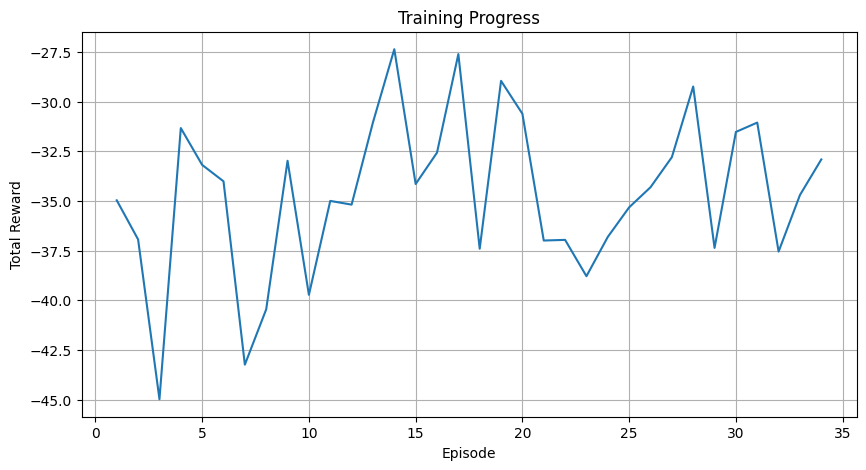

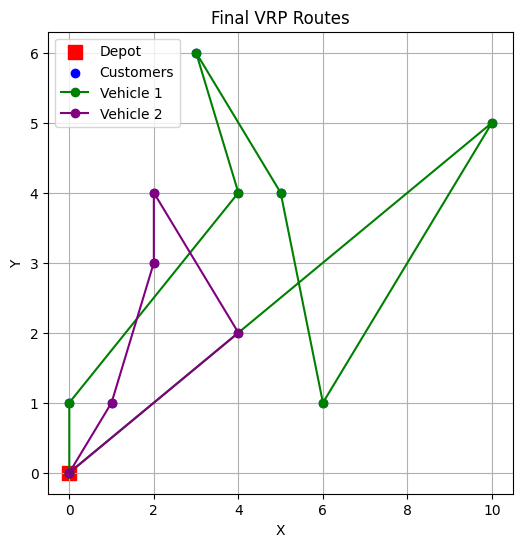

In [ ]:
"""

-------------------MAIN-------------------

Hybrid QRL for VRP with Early Stopping
- Classical attention encoder
- Quantum policy (PennyLane)
- REINFORCE training
- Adaptive early stopping
- Nearest vehicle selection
"""

import os
import random
import psutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import matplotlib.pyplot as plt

# -------------------------------
# VRP ENVIRONMENT
# -------------------------------
class VRPEnvironment:
    def __init__(self, customers, num_vehicles=2):
        self.depot = np.array([0.0, 0.0])
        self.customers = np.array(customers, dtype=float)
        self.num_customers = len(self.customers)
        self.num_vehicles = num_vehicles
        self.reset()

    def reset(self):
        self.visited = np.zeros(self.num_customers, dtype=bool)
        self.vehicle_positions = np.tile(self.depot, (self.num_vehicles, 1)).astype(float)
        self.total_distance = 0.0
        return self._get_state()

    def _distance(self, a, b):
        return np.linalg.norm(a - b)

    def _get_state(self):
        return np.concatenate([self.vehicle_positions.flatten(),
                               self.customers.flatten(),
                               self.visited.astype(float)])

    def step(self, vehicle_idx, customer_idx):
        if self.visited[customer_idx]:
            return self._get_state(), -5.0, all(self.visited), 0.0
        curr = self.vehicle_positions[vehicle_idx]
        target = self.customers[customer_idx]
        dist = self._distance(curr, target)
        self.vehicle_positions[vehicle_idx] = target.copy()
        self.visited[customer_idx] = True
        self.total_distance += dist
        done = all(self.visited)
        reward = -dist
        return self._get_state(), reward, done, dist

# -------------------------------
# QUANTUM CIRCUIT
# -------------------------------
n_qubits = 6
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def q_policy_qnode(encoded_angles, q_weights):
    for i in range(n_qubits):
        qml.RY(encoded_angles[i], wires=i)
    for i in range(n_qubits):
        qml.RY(q_weights[i,0], wires=i)
        qml.RZ(q_weights[i,1], wires=i)
        qml.RX(q_weights[i,2], wires=i)
    for i in range(n_qubits-1):
        qml.CNOT(wires=[i,i+1])
    qml.CNOT(wires=[n_qubits-1,0])
    return qml.expval(qml.PauliZ(0))

# -------------------------------
# HYBRID QRL POLICY
# -------------------------------
class HybridQRLPolicy(nn.Module):
    def __init__(self, embed_dim=64, n_heads=4, n_qubits_local=n_qubits):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_heads = n_heads
        self.n_qubits = n_qubits_local

        self.customer_embed = nn.Sequential(
            nn.Linear(3, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        self.vehicle_embed = nn.Sequential(
            nn.Linear(2, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        self.attention = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.classical_to_qubits = nn.Linear(embed_dim, self.n_qubits)
        self.q_weights = nn.Parameter(0.01 * torch.randn(self.n_qubits,3,dtype=torch.float32))
        self.post_proc = nn.Linear(1,1)

    def forward(self, vehicle_positions_np, customer_positions_np, visited_mask_np):
        device = next(self.parameters()).device
        vehicle_positions = torch.tensor(vehicle_positions_np, dtype=torch.float32, device=device)
        customer_positions = torch.tensor(customer_positions_np, dtype=torch.float32, device=device)
        visited_mask = torch.tensor(visited_mask_np, dtype=torch.float32, device=device)

        num_vehicles = vehicle_positions.shape[0]
        num_customers = customer_positions.shape[0]

        customer_input = torch.cat([customer_positions, visited_mask.unsqueeze(1)], dim=1)
        cust_emb = self.customer_embed(customer_input)
        veh_emb = self.vehicle_embed(vehicle_positions)
        queries = veh_emb.unsqueeze(0)
        keys_values = cust_emb.unsqueeze(0)
        attn_output, _ = self.attention(queries, keys_values, keys_values)
        attn_output = attn_output.squeeze(0)

        scores = torch.zeros((num_vehicles, num_customers), device=device, dtype=torch.float32)

        for v in range(num_vehicles):
            v_vec = attn_output[v].unsqueeze(0)
            pair_features = v_vec * cust_emb
            angles = self.classical_to_qubits(pair_features)
            angles = torch.tanh(angles) * np.pi
            for c in range(num_customers):
                if visited_mask[c] >= 0.5:
                    scores[v,c] = -1e6
                    continue
                encoded_angles = angles[c]
                q_out = q_policy_qnode(encoded_angles, self.q_weights)
                q_out = q_out.to(torch.float32)  # <-- fix for double/float mismatch
                q_score = self.post_proc(q_out.unsqueeze(0)).squeeze(0)
                scores[v,c] = (q_score + 1.0) * 0.5
        probs = torch.softmax(scores, dim=1)
        return probs

# -------------------------------
# TRAINING WITH EARLY STOPPING
# -------------------------------
def train_hybrid_qrl(customers, num_vehicles=2, max_episodes=1000, patience=100, lr=0.01, device="cpu"):
    env = VRPEnvironment(customers, num_vehicles=num_vehicles)
    policy = HybridQRLPolicy().to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    best_distance = float("inf")
    best_route = None
    episode_rewards = []
    mem_usage_records = []
    no_improve_counter = 0

    ep = 0
    while ep < max_episodes:
        ep += 1
        state = env.reset()
        total_reward = 0.0
        route_log = [[] for _ in range(num_vehicles)]
        done = False
        steps = 0

        while not done and steps < 200:
            vehicle_positions = env.vehicle_positions.copy()
            customer_positions = env.customers.copy()
            visited_mask = env.visited.astype(float)
            probs = policy(vehicle_positions, customer_positions, visited_mask)
            flat = probs.detach().cpu().numpy().flatten()
            flat = np.maximum(flat, 0)
            if flat.sum() == 0:
                break
            flat /= flat.sum()
            idx = np.random.choice(len(flat), p=flat)
            vehicle_idx = idx // env.num_customers
            customer_idx = idx % env.num_customers

            # Nearest vehicle logic
            customer_pos = env.customers[customer_idx]
            distances = [env._distance(pos, customer_pos) for pos in env.vehicle_positions]
            min_dist = min(distances)
            candidates = [i for i,d in enumerate(distances) if d==min_dist]
            if vehicle_idx not in candidates:
                vehicle_idx = random.choice(candidates)

            _, reward, done, dist = env.step(vehicle_idx, customer_idx)
            total_reward += reward
            route_log[vehicle_idx].append(f"C{customer_idx+1}")

            optimizer.zero_grad()
            probs_tensor = policy(vehicle_positions, customer_positions, visited_mask)
            prob_taken = probs_tensor[vehicle_idx, customer_idx]
            loss = -torch.log(prob_taken + 1e-8) * reward
            loss.backward()
            optimizer.step()
            steps += 1

        episode_rewards.append(total_reward)
        mem_usage_records.append(psutil.Process(os.getpid()).memory_info().rss / (1024*1024))

        if env.total_distance < best_distance:
            best_distance = env.total_distance
            best_route = route_log
            no_improve_counter = 0
        else:
            no_improve_counter += 1

        print(f"Episode {ep}  Distance: {env.total_distance:.3f}  Reward: {total_reward:.3f}  Mem(MB): {mem_usage_records[-1]:.1f}")

        if no_improve_counter >= patience:
            print(f"\nStopping early at episode {ep} (no improvement in {patience} episodes)")
            break

    return policy, best_route, best_distance, episode_rewards, np.mean(mem_usage_records)

# -------------------------------
# VISUALIZATION
# -------------------------------
def plot_training(rewards):
    plt.figure(figsize=(10,5))
    plt.plot(range(1,len(rewards)+1), rewards)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Training Progress")
    plt.grid(True)
    plt.show()

def plot_vrp_route(customers, route_log):
    plt.figure(figsize=(6,6))
    depot = np.array([0,0])
    plt.scatter(*depot, c='red', marker='s', s=100, label='Depot')
    cust_array = np.array(customers)
    plt.scatter(cust_array[:,0], cust_array[:,1], c='blue', label='Customers')
    colors = ['green','purple','orange','cyan','magenta']
    for v_idx, route in enumerate(route_log):
        if not route:
            continue
        positions = [depot] + [customers[int(r[1:])-1] for r in route] + [depot]
        positions = np.array(positions)
        plt.plot(positions[:,0], positions[:,1], marker='o', color=colors[v_idx % len(colors)], label=f"Vehicle {v_idx+1}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Final VRP Routes")
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------------
# MAIN
# -------------------------------
if __name__ == "__main__":
    customers = [
        (2, 3), (5, 4), (6, 1), (3, 6), (4, 2),
        (0, 1), (10, 5), (1, 1), (2, 4), (4, 4)
    ]
    num_vehicles = 2

    policy, best_route, best_distance, rewards, avg_mem = train_hybrid_qrl(
        customers, num_vehicles=num_vehicles, max_episodes=1000, patience=20, lr=0.01, device="cpu"
    )

    # Save the trained model
    save_path = "hybrid_qrl_policy.pth"
    torch.save(policy.state_dict(), save_path)

    # Print confirmation and full path
    full_path = os.path.abspath(save_path)
    print(f"✅ Hybrid QRL model saved successfully at: {full_path}")


    print("\n=== Training Finished ===")
    print(f"Best Distance: {best_distance:.3f}")
    print(f"Best Route: {best_route}")
    print(f"Average Memory Usage: {avg_mem:.2f} MB")

    plot_training(rewards)
    plot_vrp_route(customers, best_route)


In [ ]:
import os
import torch

# Define your new dataset
new_customers = [
    (2,3),(5,4),(6,1),(3,6),(4,2),
    (0,1),(10,5),(1,1),(2,4),(4,4),
    (7,3),(8,2),(9,6),(3,8),(5,7),
    (1,5),(2,7),(6,8),(9,2),(8,5)
]
new_num_vehicles = 4
device = "cpu"

# Initialize the policy
policy = HybridQRLPolicy().to(device)

# Load previously saved weights if available
saved_model_path = "/content/hybrid_qrl_policy.pth"
if os.path.exists(saved_model_path):
    policy.load_state_dict(torch.load(saved_model_path, map_location=device))
    print(f"✅ Loaded saved model from: {saved_model_path}")
else:
    print("⚠️ Saved model not found. Training from scratch.")

# Train/fine-tune on new dataset
policy, best_route, best_distance, rewards, avg_mem = train_hybrid_qrl(
    new_customers, num_vehicles=new_num_vehicles,
    max_episodes=1000, patience=20, lr=0.01, device=device
)

# Save the fine-tuned model
torch.save(policy.state_dict(), saved_model_path)
print(f"✅ Fine-tuned model saved at: {os.path.abspath(saved_model_path)}")

# Show results
print("\n=== Fine-Tuning Finished ===")
print(f"Best Distance: {best_distance:.3f}")
print(f"Best Route: {best_route}")
print(f"Average Memory Usage: {avg_mem:.2f} MB")

# Visualize
plot_training(rewards)
plot_vrp_route(new_customers, best_route)


✅ Loaded saved model from: /content/hybrid_qrl_policy.pth


TypeError: train_hybrid_qrl() got an unexpected keyword argument 'max_episodes'

✅ Loaded trained model for testing.

=== Test Finished ===
Vehicle 1 route: Depot -> C4 -> C2 -> C1 -> Depot
Vehicle 2 route: Depot -> C3 -> Depot
Total Distance: 15.575


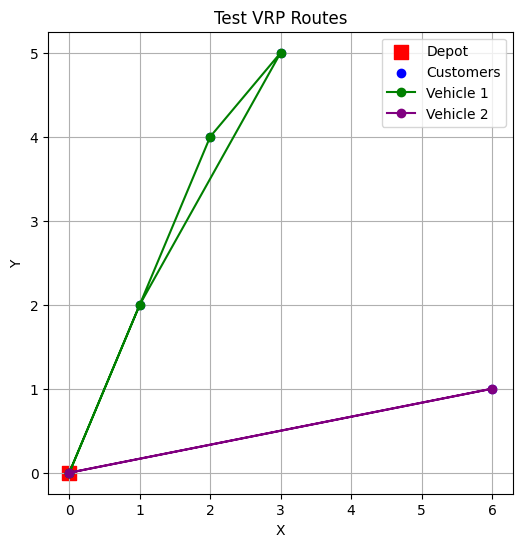

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


device = "cpu"


test_customers = [
    (1, 2), (3, 5), (6, 1), (2, 4)
]
num_test_vehicles = 2


policy = HybridQRLPolicy().to(device)
model_path = "/content/hybrid_qrl_policy.pth"
policy.load_state_dict(torch.load(model_path, map_location=device))
policy.eval()
print("✅ Loaded trained model for testing.")


class VRPEnvironmentTest:
    def __init__(self, customers, num_vehicles):
        self.depot = np.array([0.0, 0.0])
        self.customers = np.array(customers, dtype=float)
        self.num_customers = len(customers)
        self.num_vehicles = num_vehicles
        self.reset()

    def reset(self):
        self.visited = np.zeros(self.num_customers, dtype=bool)
        self.vehicle_positions = np.tile(self.depot, (self.num_vehicles, 1)).astype(float)
        self.total_distance = 0.0
        return self._get_state()

    def _distance(self, a, b):
        return np.linalg.norm(a - b)

    def _get_state(self):
        return np.concatenate([self.vehicle_positions.flatten(),
                               self.customers.flatten(),
                               self.visited.astype(float)])

    def step(self, vehicle_idx, customer_idx):
        if self.visited[customer_idx]:
            return self._get_state(), -5.0, all(self.visited), 0.0
        curr = self.vehicle_positions[vehicle_idx]
        target = self.customers[customer_idx]
        dist = self._distance(curr, target)
        self.vehicle_positions[vehicle_idx] = target.copy()
        self.visited[customer_idx] = True
        self.total_distance += dist
        done = all(self.visited)
        reward = -dist
        return self._get_state(), reward, done, dist

env = VRPEnvironmentTest(test_customers, num_test_vehicles)
route_log = [[] for _ in range(num_test_vehicles)]
done = False
steps = 0

while not done and steps < 200:
    vehicle_positions = env.vehicle_positions.copy()
    customer_positions = env.customers.copy()
    visited_mask = env.visited.astype(float)

    with torch.no_grad():
        probs = policy(vehicle_positions, customer_positions, visited_mask)

    flat = probs.cpu().numpy().flatten()
    flat = np.maximum(flat, 0)
    if flat.sum() == 0:
        break
    flat /= flat.sum()
    idx = np.random.choice(len(flat), p=flat)
    vehicle_idx = idx // env.num_customers
    customer_idx = idx % env.num_customers

    customer_pos = env.customers[customer_idx]
    distances = [env._distance(pos, customer_pos) for pos in env.vehicle_positions]
    min_dist = min(distances)
    candidates = [i for i,d in enumerate(distances) if d==min_dist]
    if vehicle_idx not in candidates:
        vehicle_idx = np.random.choice(candidates)

    _, _, done, _ = env.step(vehicle_idx, customer_idx)
    route_log[vehicle_idx].append(f"C{customer_idx+1}")
    steps += 1


print("\n=== Test Finished ===")
for v_idx, route in enumerate(route_log):
    print(f"Vehicle {v_idx+1} route: Depot -> {' -> '.join(route)} -> Depot")
print(f"Total Distance: {env.total_distance:.3f}")


def plot_vrp_route(customers, route_log):
    plt.figure(figsize=(6,6))
    depot = np.array([0,0])
    plt.scatter(*depot, c='red', marker='s', s=100, label='Depot')
    cust_array = np.array(customers)
    plt.scatter(cust_array[:,0], cust_array[:,1], c='blue', label='Customers')
    colors = ['green','purple','orange','cyan','magenta']
    for v_idx, route in enumerate(route_log):
        if not route:
            continue
        positions = [depot] + [customers[int(r[1:])-1] for r in route] + [depot]
        positions = np.array(positions)
        plt.plot(positions[:,0], positions[:,1], marker='o', color=colors[v_idx % len(colors)], label=f"Vehicle {v_idx+1}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Test VRP Routes")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_vrp_route(test_customers, route_log)
